# Unfollow research on set 1

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.exception import NetworkXError
from scipy.stats import chi2_contingency
import networkx as nx

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import igraph as ig
import leidenalg as la
from sqlalchemy.dialects.mssql.information_schema import columns

from social_graph.pipeline import *
from social_graph.metrics import *
from social_graph.describe import compare_persona_across_simulations

In [2]:
conn3 = sqlite3.connect("data/experiment_set_1/database_server_3.db")
conn4 = sqlite3.connect("data/experiment_set_1/database_server_4.db")
conn5 = sqlite3.connect("data/experiment_set_1/database_server_5.db")

connb1 = sqlite3.connect("data/experiment_set_1/database_server_b1.db")
connb2 = sqlite3.connect("data/experiment_set_1/database_server_b2.db")
connb3 = sqlite3.connect("data/experiment_set_1/database_server_b3.db")

In [3]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism', 'age', 'profession']

In [4]:
# connections = [conn3, conn4, conn5, connb1, connb2, connb3]
#
# for connection in connections:
#     personas, features_df, follow = run_simulation_preprocessing(connection,
#                                                                  label=f"Simulation_{connection}",
#                                                                  feature_cols=features_cols)
#     description, persona_dict = cluster_persona_and_analyse(personas, features_df, 4,
#                                                                label=f"Simulation_{connection}",
#                                                                feature_cols=features_cols)
#     personas

Running Simulation_3...

Data loading ...

Number of users: 1000
Total actions: 16424
Follow actions: 12317
Unfollow actions: 4107
Number of rounds: 61
Number of posts: 140111

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 25)

Searching best number of persona ...

k=2 silhouette=0.0816
k=3 silhouette=0.0961
k=4 silhouette=0.1382
k=5 silhouette=0.0972
k=6 silhouette=0.1022
k=7 silhouette=0.1138
k=8 silhouette=0.1054
k=9 silhouette=0.1170


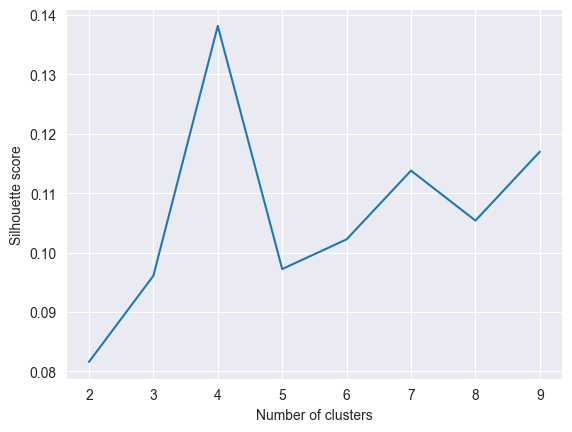


Done!
persona
Persona_3    257
Persona_4    255
Persona_2    248
Persona_1    240
Name: count, dtype: int64


,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
1,2,consistent/cautious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Skilled_Trades,female,democrat,master,Persona_2
2,3,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,sensitive/nervous,old,Skilled_Trades,male,democrat,master,Persona_3
3,4,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,master,Persona_4
4,5,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,old,Security,male,democrat,master,Persona_2
5,6,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,old,Science_Academia,male,democrat,master,Persona_3
...,...,...,...,...,...,...,...,...,...,...,...,...
996,997,inventive/curious,efficient/organized,solitary/reserved,critical/judgmental,sensitive/nervous,young,Transport,male,democrat,master,Persona_4
997,998,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,resilient/confident,middle,Security,male,democrat,master,Persona_2
998,999,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,resilient/confident,young,Agriculture,male,democrat,master,Persona_1
999,1000,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,resilient/confident,middle,Science_Academia,male,democrat,master,Persona_1


In [5]:
persona_df, features_df, follow = run_simulation_preprocessing(conn3, label='Simulation_3', feature_cols=features_cols)

k_best = 4
personas = create_personae(k_best, persona_df, features_df)
personas

In [6]:
follow.head()

,user_id,follower_id,id,action,round
0,496,245,1,follow,1
1,743,400,2,follow,1
2,679,743,3,follow,1
3,130,500,4,follow,2
4,825,837,5,follow,2


In [7]:
# follow.drop(columns=['id'], inplace=True)
# follow.drop_duplicates(inplace=True)
# follow.head()

In [8]:
# pers = personas[['id', 'persona']].reset_index()
# pers.rename(columns={'id': 'follower_id'}, inplace=True)
#
# follow = follow.merge(pers, on='follower_id', how='left')
# follow.head()

In [9]:
# follow.drop(columns=['index'], inplace=True)
# follow.head()

### Unfollows ratio

In [10]:
# unfollow = follow[follow['action']=="unfollow"]
# unfollow.head()

In [11]:
# unfollows_per_follower = (unfollow.groupby('follower_id').size().reset_index(name='n_actions'))
# unfollows_per_follower

In [12]:
# len(unfollows_per_follower[unfollows_per_follower['n_actions'] == 1])

There is 377 users who used unfollow at least once.
130 of them did it only once.

Let's plot histogram for users who did it more times.

Most of the users unfollowed others only a few times.

There are some users who used it extremely often.

In [13]:
# unfollows_per_follower_more = unfollows_per_follower[unfollows_per_follower['n_actions'] > 1].reset_index(drop=True)
#
# plt.hist(unfollows_per_follower_more['n_actions'], bins=100)
# plt.show()

In [14]:
# unfollows_per_persona = (unfollow.groupby('persona').size().reset_index(name='n_unfollows'))
# unfollows_per_persona

In [15]:
# follows_per_persona = follow[follow['action']=="follow"].groupby('persona').size().reset_index(name='n_follows')
# follows_per_persona

In [16]:
# follows_per_persona = follows_per_persona.merge(unfollows_per_persona, on='persona')
# follows_per_persona.head()

In [17]:
# follows_per_persona['ratio'] = follows_per_persona['n_unfollows'] / follows_per_persona['n_follows']
# follows_per_persona.head()

Persona 4 was described as critical, emotionally reactive, selective. It has the lowest and definitely lower unfollow/follow ratio than others personas. Persona 4 is selective what can mean that they do not accept easily new connections, so produces more stable connections. Both follows and unfollows counts remain low, so it confirms this thesis.

#### Test

Number of users who used unfollow: 377


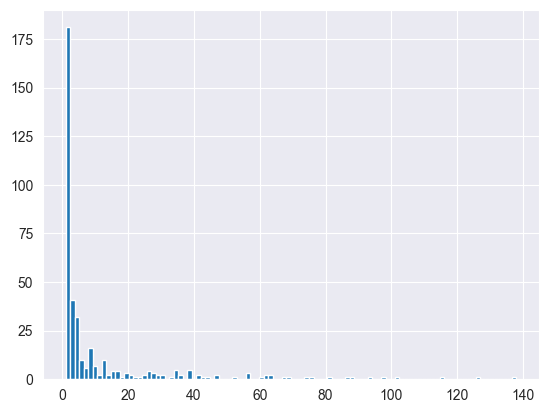

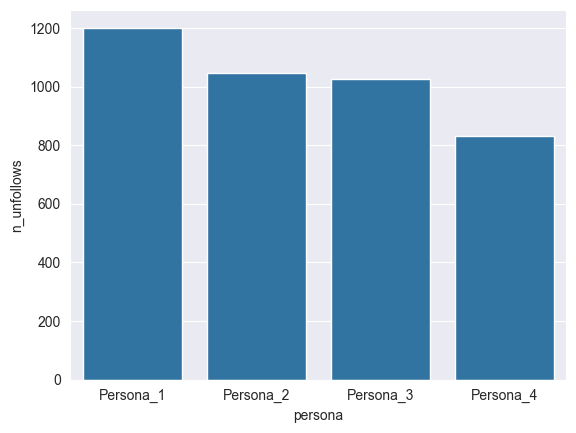

Follows & Unfollows per persona:
     persona  n_follows  n_unfollows     ratio
0  Persona_1       3397         1202  0.353842
1  Persona_2       3038         1046  0.344305
2  Persona_3       3083         1027  0.333117
3  Persona_4       2799          832  0.297249


In [18]:
follow_persona = add_persona_to_follow(follow, personas)
follow_stats = describe_unfollows(follow_persona)

### Follows + unfollows over time

In [19]:
max_round = follow['round'].max()
print(f"Rounds: {max_round}")
print(f"Days: {max_round/24}")

Rounds: 1440
Days: 60.0


In [20]:
# round_iter = 24
# counts_daily = []
#
# while round_iter <= max_round:
#     follow_r = follow[(follow['action'] == 'follow') &
#                       (follow['round'] <= round_iter)]
#     unfollow_r = unfollow[(follow['action'] == 'unfollow') &
#                           (follow['round'] <= round_iter)]
#
#     follows_per_persona = follow_r.groupby('persona').size().reset_index(name='n_follows')
#     unfollows_per_persona = unfollow_r.groupby('persona').size().reset_index(name='n_unfollows')
#
#     df = follows_per_persona.merge(unfollows_per_persona, on='persona', how='outer').fillna(0)
#
#     df['neighbourhood'] = df['n_follows'] - df['n_unfollows']
#     df['day'] = round_iter / 24
#
#     counts_daily.append(df)
#
#     round_iter += 24 # 1 round = 1 hour
#
# follows_daily = pd.concat(counts_daily, ignore_index=True)
# follows_daily

In [21]:
# plt.figure(figsize = (12,6))
#
# sns.lineplot(
#     data=follows_daily,
#     x='day',
#     y='n_follows',
#     hue='persona'
# )
#
# plt.title('Follows growth over time')
# plt.show()

In [22]:
# plt.figure(figsize = (12,6))
#
# sns.lineplot(
#     data=follows_daily,
#     x='day',
#     y='n_unfollows',
#     hue='persona'
# )
#
# plt.title('Unfollows growth over time')
# plt.show()

In [23]:
# plt.figure(figsize = (12,6))
#
# sns.lineplot(
#     data=follows_daily,
#     x='day',
#     y='neighbourhood',
#     hue='persona'
# )
#
# plt.title('Neighbourhood growth over time')
# plt.show()

#### Test

Rounds: 1440
Days: 60.0


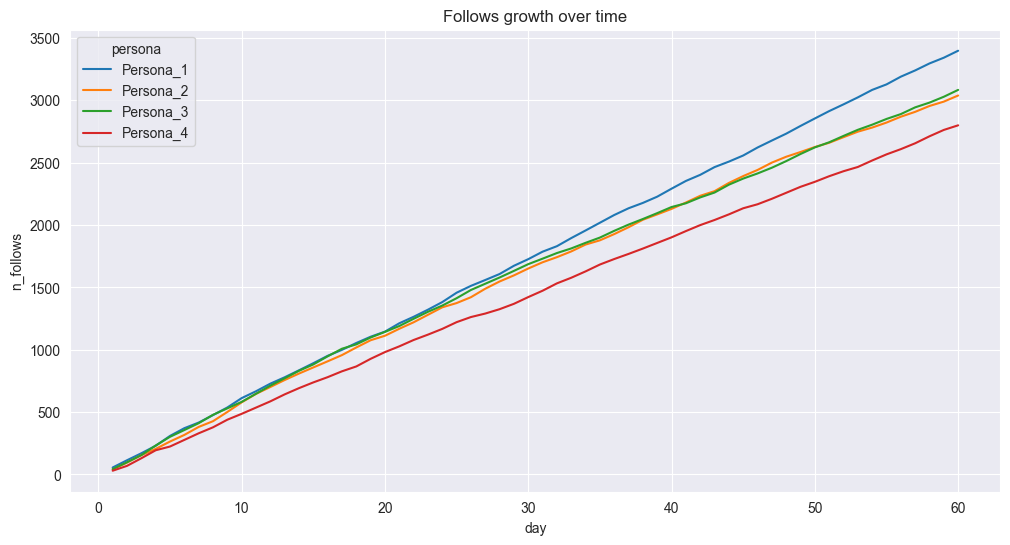

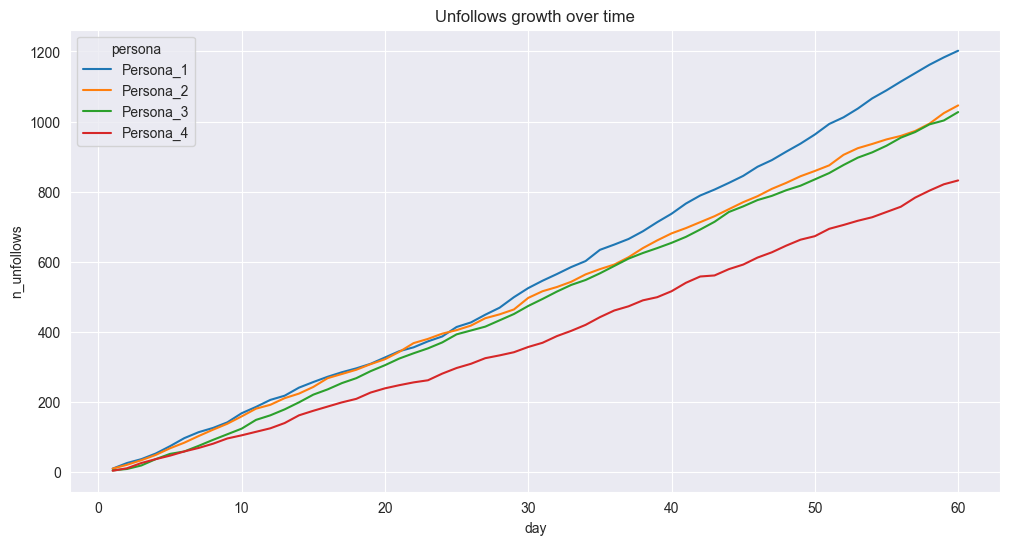

,persona,n_follows,n_unfollows,day
0,Persona_1,56,10,1
1,Persona_2,41,10,1
2,Persona_3,43,5,1
3,Persona_4,30,4,1
4,Persona_1,114,26,2


In [24]:
follows_over_time = describe_follows_over_time(follow_persona)
follows_over_time.head()

### Lifespan of connections

In [25]:
follow_persona

,user_id,follower_id,id,action,round,persona
0,496,245,1,follow,1,Persona_4
1,743,400,2,follow,1,Persona_3
2,679,743,3,follow,1,Persona_4
3,130,500,4,follow,2,Persona_2
4,825,837,5,follow,2,Persona_1
...,...,...,...,...,...,...
16419,862,945,16420,follow,1440,Persona_2
16420,159,965,16421,unfollow,1440,Persona_1
16421,29,925,16422,follow,1440,Persona_4
16422,174,500,16423,unfollow,1440,Persona_2


In [38]:
lifespan_df = follow_persona.sort_values(['follower_id', 'user_id', 'id'])
lifespan_df.head()

,user_id,follower_id,id,action,round,persona
3235,345,2,3236,follow,277,Persona_2
2047,892,2,2048,follow,183,Persona_2
10791,991,2,10792,follow,938,Persona_2
15159,319,3,15160,follow,1330,Persona_3
256,485,3,257,follow,33,Persona_3


In [61]:
lifespans = []
invalid_unfollows_counts = 0

for (u, v, persona), group in lifespan_df.groupby(['follower_id', 'user_id', 'persona']):
    start = None

    for _, row in group.iterrows():
        if row['action'] == 'follow':
            start = row['round']
        elif row['action'] == 'unfollow' and start is not None:
            lifespan = (row['round'] - start) / 24
            lifespans.append((persona, u, v, lifespan))
            start = None
        elif row['action'] == 'unfollow' and start is None:
            print(f"Invalid unfollow action for users {u} -> {v}: {row['action']}")
            invalid_unfollows_counts += 1

    if start is not None:
        lifespans.append((persona, u, v, '+')) # connection still exist

print(f"Invalid unfollow actions: {invalid_unfollows_counts}")

lifespans = pd.DataFrame(lifespans, columns=['persona', 'follower_id', 'user_id', 'lifespan(days)'])
lifespans

Invalid unfollow action for users 8 -> 342: unfollow
Invalid unfollow action for users 12 -> 333: unfollow
Invalid unfollow action for users 12 -> 679: unfollow
Invalid unfollow action for users 12 -> 690: unfollow
Invalid unfollow action for users 17 -> 32: unfollow
Invalid unfollow action for users 17 -> 323: unfollow
Invalid unfollow action for users 17 -> 341: unfollow
Invalid unfollow action for users 17 -> 500: unfollow
Invalid unfollow action for users 17 -> 914: unfollow
Invalid unfollow action for users 17 -> 934: unfollow
Invalid unfollow action for users 20 -> 109: unfollow
Invalid unfollow action for users 20 -> 819: unfollow
Invalid unfollow action for users 21 -> 459: unfollow
Invalid unfollow action for users 23 -> 21: unfollow
Invalid unfollow action for users 27 -> 21: unfollow
Invalid unfollow action for users 27 -> 152: unfollow
Invalid unfollow action for users 67 -> 502: unfollow
Invalid unfollow action for users 72 -> 679: unfollow
Invalid unfollow action for user

,persona,follower_id,user_id,lifespan(days)
0,Persona_2,2,345,+
1,Persona_2,2,892,+
2,Persona_2,2,991,+
3,Persona_3,3,319,+
4,Persona_3,3,485,+
...,...,...,...,...
12127,Persona_2,1001,148,+
12128,Persona_2,1001,294,+
12129,Persona_2,1001,650,+
12130,Persona_2,1001,711,+


In [62]:
lifespans['is_existing'] = lifespans['lifespan(days)'] == '+'
lifespans['lifespan_num'] = pd.to_numeric(
    lifespans['lifespan(days)'],
    errors='coerce'   # "+" → NaN
)
lifespan_summary = lifespans.groupby('persona').agg(
    total=('lifespan(days)', 'count'),
    existing=('is_existing', 'sum'),
    removed=('lifespan_num', 'count'),
    lifespan_mean=('lifespan_num', 'mean'),
    lifespan_std=('lifespan_num', 'std'),
    lifespan_median=('lifespan_num', 'median')
)

lifespan_summary['survival_rate'] = lifespan_summary['existing'] / lifespan_summary['total']

lifespan_summary

,total,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate
persona,,,,,,,
Persona_1,3350,2214,1136,11.225169,12.357774,6.541667,0.660896
Persona_2,2984,2001,983,10.090031,11.556975,5.708333,0.670576
Persona_3,3038,2067,971,10.473438,11.696247,6.208333,0.680382
Persona_4,2760,1966,794,11.121956,11.943921,7.333333,0.712319


**Observation:** Persona_2 generates the most short-lived interactions, while Persona_4 forms fewer but more persistent connections; Persona_1 dominates in volume, and Persona_3 remains neutral.

### Neighborhood over time

Persona creation ...

persona
Persona_3    257
Persona_4    255
Persona_2    248
Persona_1    240
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 0.3435675936396342
conscientiousness: 0.3511976933463813
extroversion: 1.2544441350646485e-105
agreeableness: 7.220419696004772e-111
neuroticism: 1.7994208765314067e-216
age: 0.005018962218650817
profession: 0.07484624611831255


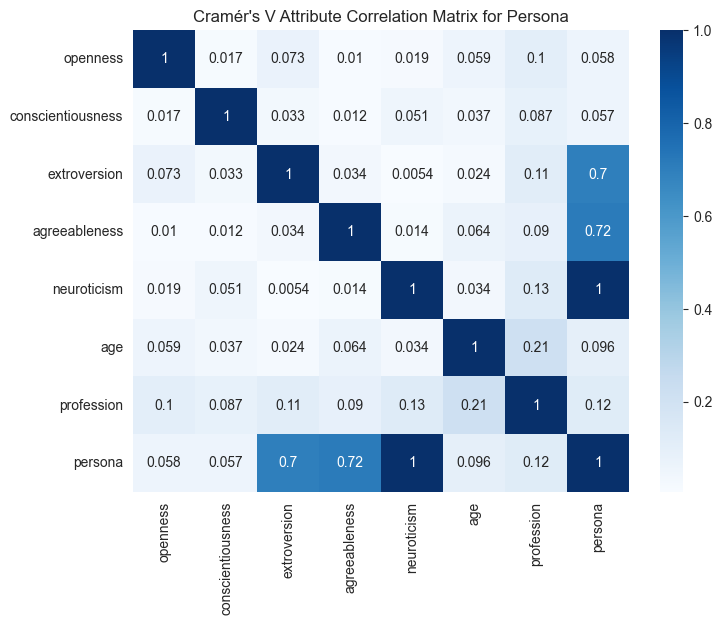

In [26]:
k_best = 4
description, persona_dict = cluster_persona_and_analyse(personas, features_df, k_best)

In [27]:
G, G_lcc = create_graph(follow)

nx.set_node_attributes(G, persona_dict, "persona")
nx.set_node_attributes(G_lcc, persona_dict, "persona")

Number of nodes: 892
Number of edges: 8248
Number of connective components: 16
Components sizes: [877, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of nodes (LCC): 877
Number of edges (LCC): 8248


In [28]:
# plt.figure(figsize=(8, 6))
# nx.draw(G, node_size=20, arrowsize=10)
# plt.title("Final network (with unfollows)")
# plt.show()

In [29]:
from collections import defaultdict, Counter

def group_nodes_by_persona(G):
    persona_groups = defaultdict(list)

    for node, data in G.nodes(data=True):
        persona = data.get("persona")
        persona_groups[persona].append(node)

    return persona_groups

In [30]:
persona_groups = group_nodes_by_persona(G)
persona_groups

defaultdict(list,
            {'Persona_4': [245,
              743,
              51,
              411,
              654,
              109,
              432,
              711,
              470,
              426,
              760,
              27,
              406,
              223,
              29,
              889,
              435,
              307,
              997,
              495,
              681,
              853,
              336,
              345,
              646,
              502,
              848,
              233,
              372,
              294,
              75,
              464,
              595,
              138,
              401,
              718,
              551,
              150,
              42,
              883,
              585,
              541,
              705,
              987,
              311,
              893,
              534,
              76,
              616,
              155,
              463,
      

In [31]:
def aggregate_neighbor_personas(G, persona_groups):
    persona_neighbor_counts = {}

    for persona, nodes in persona_groups.items():
        counter = Counter()

        for node in nodes:
            neighbors = G.neighbors(node)
            neighbor_personas = [
                G.nodes[n].get("persona") for n in neighbors
            ]
            counter.update(neighbor_personas)

        persona_neighbor_counts[persona] = counter

    return persona_neighbor_counts

In [32]:
persona_neighbor_counts = aggregate_neighbor_personas(G, persona_groups)
persona_neighbor_counts

{'Persona_4': Counter({'Persona_1': 578,
          'Persona_3': 506,
          'Persona_2': 462,
          'Persona_4': 420}),
 'Persona_3': Counter({'Persona_1': 581,
          'Persona_3': 546,
          'Persona_2': 496,
          'Persona_4': 444}),
 'Persona_2': Counter({'Persona_1': 569,
          'Persona_3': 521,
          'Persona_2': 462,
          'Persona_4': 449}),
 'Persona_1': Counter({'Persona_1': 639,
          'Persona_3': 572,
          'Persona_4': 504,
          'Persona_2': 499})}

Persona 1 has the most connections (follow actions) so it occupies top ranks across all personas.

In [33]:
def aggregate_neighbor_personas(G, persona_groups):
    persona_neighbor_counts = {}
    persona_neighbor_size = {}

    for persona, nodes in persona_groups.items():
        counter = Counter()

        neighbors_set = set()

        for node in nodes:
            neighbors_set.update(G.neighbors(node))

            counter = Counter(G.nodes[n]["persona"] for n in neighbors_set)

        persona_neighbor_counts[persona] = counter
        persona_neighbor_size[persona] = len(neighbors_set)

    return persona_neighbor_counts, persona_neighbor_size

In [34]:
persona_neighbor_counts, persona_neighbor_size = aggregate_neighbor_personas(G, persona_groups)
persona_neighbor_counts

{'Persona_4': Counter({'Persona_1': 126,
          'Persona_3': 119,
          'Persona_4': 112,
          'Persona_2': 112}),
 'Persona_3': Counter({'Persona_2': 131,
          'Persona_3': 121,
          'Persona_1': 120,
          'Persona_4': 117}),
 'Persona_2': Counter({'Persona_1': 129,
          'Persona_2': 121,
          'Persona_4': 121,
          'Persona_3': 121}),
 'Persona_1': Counter({'Persona_3': 130,
          'Persona_1': 127,
          'Persona_4': 114,
          'Persona_2': 106})}

Here we consider neighborhood set for particular personas. For distinct personas different personas types dominate neighborhoods. Below neighborhood size for personas (unique nodes).

In [35]:
persona_neighbor_size

{'Persona_4': 469, 'Persona_3': 489, 'Persona_2': 492, 'Persona_1': 477}

In [36]:
def describe_neighborhood_over_time(follow_df, persona_dict, round_step=24):
    """
    Neighborhoods sizes analyses for personas groups over time. Generates plots.
    :param follow_df: follow table already merged with personas.
    """
    max_round = follow_df['round'].max()
    print(f"Rounds: {max_round}")
    print(f"Days: {max_round / 24}")

    round_iter = round_step
    counts_daily = []

    while round_iter <= max_round:
        follow_r = follow_df[follow_df['round'] <= round_iter]

        G, G_lcc = create_graph(follow_r)
        nx.set_node_attributes(G, persona_dict, "persona")

        persona_neighborhood_size = {}
        persona_groups = group_nodes_by_persona(G)

        for persona, nodes in persona_groups.items():
            counter = Counter()

            neighbors_set = set()

            for node in nodes:
                neighbors_set.update(G.neighbors(node))
                counter = Counter(G.nodes[n]["persona"] for n in neighbors_set)

            persona_neighborhood_size[persona] = len(neighbors_set)

        df = pd.DataFrame(
            list(persona_neighborhood_size.items()),
            columns=["persona", "neighborhood_size"]
        )

        df['day'] = round_iter // 24

        counts_daily.append(df)

        round_iter += round_step

    neighborhood_daily = pd.concat(counts_daily, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=neighborhood_daily,
        x='day',
        y='neighborhood_size',
        hue='persona'
    )
    plt.title('Neighborhood over time')
    plt.show()

    return neighborhood_daily

Rounds: 1440
Days: 60.0
Number of nodes: 140
Number of edges: 144
Number of connective components: 26
Components sizes: [88, 1, 2, 1, 2, 2, 1, 2, 2, 4, 4, 1, 1, 3, 3, 4, 2, 2, 2, 1, 3, 2, 2, 2, 2, 1]
Number of nodes (LCC): 88
Number of edges (LCC): 117
Number of nodes: 240
Number of edges: 310
Number of connective components: 26
Components sizes: [193, 1, 2, 2, 4, 1, 1, 3, 2, 2, 1, 1, 2, 2, 3, 2, 3, 1, 3, 1, 2, 2, 2, 2, 1, 1]
Number of nodes (LCC): 193
Number of edges (LCC): 288
Number of nodes: 312
Number of edges: 499
Number of connective components: 30
Components sizes: [262, 1, 2, 4, 1, 1, 3, 3, 1, 1, 2, 2, 3, 1, 1, 3, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2]
Number of nodes (LCC): 262
Number of edges (LCC): 478
Number of nodes: 371
Number of edges: 695
Number of connective components: 34
Components sizes: [320, 1, 1, 1, 3, 1, 3, 1, 2, 2, 3, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1]
Number of nodes (LCC): 320
Number of edges (LCC): 677
Number of nodes: 4

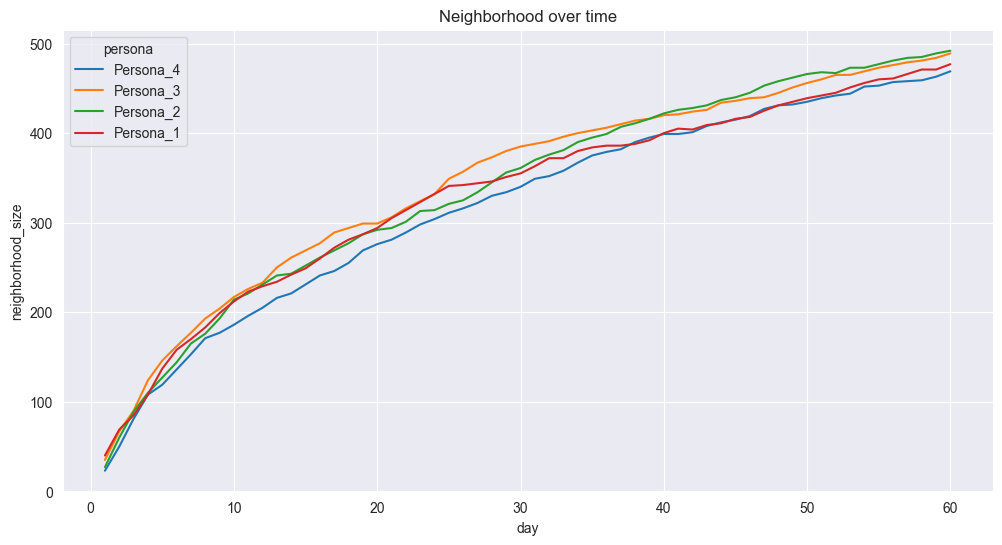

,persona,neighborhood_size,day
0,Persona_4,23,1
1,Persona_3,35,1
2,Persona_2,27,1
3,Persona_1,40,1
4,Persona_4,50,2
...,...,...,...
235,Persona_1,471,59
236,Persona_4,469,60
237,Persona_3,489,60
238,Persona_2,492,60


In [37]:
neighborhood_daily = describe_neighborhood_over_time(follow, persona_dict)
neighborhood_daily

At the beginning each node explores new parts of the graph, later neighbors of nodes start overlapping heavily, due to finite number of nodes and "connect to already well-connected nodes".

### Similarity of neighborhoods - Jaccard similarity

In [82]:
follow

,user_id,follower_id,id,action,round
0,496,245,1,follow,1
1,743,400,2,follow,1
2,679,743,3,follow,1
3,130,500,4,follow,2
4,825,837,5,follow,2
...,...,...,...,...,...
16419,862,945,16420,follow,1440
16420,159,965,16421,unfollow,1440
16421,29,925,16422,follow,1440
16422,174,500,16423,unfollow,1440


In [83]:
def jaccard_similarity(follow_df, persona_dict, round_step=24):

    def get_neighbors_safe(G, node):
        if node in G:
            return set(G.neighbors(node))
        else:
            return set()

    max_round = follow_df['round'].max()
    days = max_round // 24
    print(f"Rounds: {max_round}")
    print(f"Days: {days}")

    round_iter = round_step
    graphs = {}

    while round_iter <= max_round:
        follow_r = follow_df[follow_df['round'] <= round_iter]

        G, G_lcc = create_graph(follow_r)
        nx.set_node_attributes(G, persona_dict, "persona")

        graphs[round_iter / 24] = G
        round_iter += round_step

    jaccard_scores = []

    for node in graphs[int(days)].nodes():
        persona = persona_dict[node]
        for t in range(1, days):
            n1 = get_neighbors_safe(graphs[t], node)
            n2 = get_neighbors_safe(graphs[t+1], node)

            if len(n1 | n2) == 0:
                continue

            j = len(n1 & n2) / len(n1 | n2)
            jaccard_scores.append((node, persona, t, j))

    jaccard_scores_df = pd.DataFrame(jaccard_scores, columns=["node", "persona", "day", "score"])

    return jaccard_scores_df

In [84]:
js_df = jaccard_similarity(follow, persona_dict, round_step=24)
js_df.head()

Rounds: 1440
Days: 60
Number of nodes: 140
Number of edges: 144
Number of connective components: 26
Components sizes: [88, 1, 2, 1, 2, 2, 1, 2, 2, 4, 4, 1, 1, 3, 3, 4, 2, 2, 2, 1, 3, 2, 2, 2, 2, 1]
Number of nodes (LCC): 88
Number of edges (LCC): 117
Number of nodes: 240
Number of edges: 310
Number of connective components: 26
Components sizes: [193, 1, 2, 2, 4, 1, 1, 3, 2, 2, 1, 1, 2, 2, 3, 2, 3, 1, 3, 1, 2, 2, 2, 2, 1, 1]
Number of nodes (LCC): 193
Number of edges (LCC): 288
Number of nodes: 312
Number of edges: 499
Number of connective components: 30
Components sizes: [262, 1, 2, 4, 1, 1, 3, 3, 1, 1, 2, 2, 3, 1, 1, 3, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 2]
Number of nodes (LCC): 262
Number of edges (LCC): 478
Number of nodes: 371
Number of edges: 695
Number of connective components: 34
Components sizes: [320, 1, 1, 1, 3, 1, 3, 1, 2, 2, 3, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1]
Number of nodes (LCC): 320
Number of edges (LCC): 677
Number of nodes: 416

,node,persona,day,score
0,245,Persona_4,1,0.400000
1,245,Persona_4,2,0.600000
2,245,Persona_4,3,0.555556
3,245,Persona_4,4,0.800000
4,245,Persona_4,5,0.615385
...,...,...,...,...
36652,797,Persona_4,59,1.000000
36653,357,Persona_3,58,0.000000
36654,357,Persona_3,59,1.000000
36655,728,Persona_4,58,0.000000


- 1.0 → neighborhood didn’t change
- 0.0 → completely different neighbors
- ~0.5 → moderate change

I don't know how reliable it is for such a small graph at the beginning.



In [85]:
js_df[['persona', 'day', 'score']].groupby(['persona', 'day']).agg(
    mean=('score', 'mean'),
    std=('score', 'std'),
    median=('score', 'median')
)

mean       std    median
persona   day                              
Persona_1 1    0.502652  0.431690  0.500000
          2    0.628816  0.409605  0.750000
          3    0.689250  0.363998  0.845238
          4    0.690079  0.351426  0.833333
          5    0.827707  0.275764  1.000000
...                 ...       ...       ...
Persona_4 55   0.974397  0.110814  1.000000
          56   0.981739  0.080119  1.000000
          57   0.970351  0.115279  1.000000
          58   0.974300  0.108934  1.000000
          59   0.986844  0.049835  1.000000

[236 rows x 3 columns]

In [86]:
js_df[['persona', 'score']].groupby('persona').agg(
    mean=('score', 'mean'),
    std=('score', 'std'),
    median=('score', 'median')
)

,mean,std,median
persona,,,
Persona_1,0.942588,0.167206,1.0
Persona_2,0.944477,0.170637,1.0
Persona_3,0.948162,0.164242,1.0
Persona_4,0.945905,0.171601,1.0


The Jaccard similarity analysis indicates a high level of stability in agents’ local neighborhoods over time, with mean values exceeding 0.94 for all personas and median values equal to 1.0. This suggests that once connections are formed, they tend to persist, and agents rarely change their interaction partners.

Importantly, no meaningful differences between personas are observed. All persona types exhibit nearly identical distributions of Jaccard similarity, indicating that neighborhood stability is not influenced by persona characteristics.

Overall, the metric appears to be dominated by the persistence of edges rather than behavioral differences, limiting its usefulness for distinguishing between persona types in this setting.

In [88]:
persona_df.to_csv('data/experiment_set_1/persona_df.csv')